# Spotify API and Python

Inspired by https://stmorse.github.io/journal/spotify-api.html

We define Keys and connect to Spotify

In [11]:
import requests

CLIENT_ID = '945a8f0401e34e16967ca3e28630dd46'
CLIENT_SECRET = 'f38b15838b2c41918ff4569ee372e49b'

In [12]:
AUTH_URL = 'https://accounts.spotify.com/api/token'

# POST
auth_response = requests.post(AUTH_URL, {
    'grant_type': 'client_credentials',
    'client_id': CLIENT_ID,
    'client_secret': CLIENT_SECRET,
})

# convert the response to JSON
auth_response_data = auth_response.json()

# save the access token
access_token = auth_response_data['access_token']

In [13]:
headers = {
    'Authorization': 'Bearer {token}'.format(token=access_token)
}

Let’s start with checking out the audio features for a specific track, using the audio-features endpoint.

We need the Track ID. For instance: 6DzBTj1UCr1BvzNX3Pm5rL

https://open.spotify.com/intl-es/track/6DzBTj1UCr1BvzNX3Pm5rL

In [18]:
# base URL of all Spotify API endpoints
BASE_URL = 'https://api.spotify.com/v1/'

# Track ID from the URI
track_id = '6DzBTj1UCr1BvzNX3Pm5rL'

# actual GET request with proper header
r = requests.get(BASE_URL + 'audio-features/' + track_id, headers=headers)

In [19]:
r = r.json()
r

{'danceability': 0.471,
 'energy': 0.916,
 'key': 0,
 'loudness': -4.42,
 'mode': 0,
 'speechiness': 0.0632,
 'acousticness': 0.0512,
 'instrumentalness': 0.0301,
 'liveness': 0.172,
 'valence': 0.92,
 'tempo': 154.807,
 'type': 'audio_features',
 'id': '6DzBTj1UCr1BvzNX3Pm5rL',
 'uri': 'spotify:track:6DzBTj1UCr1BvzNX3Pm5rL',
 'track_href': 'https://api.spotify.com/v1/tracks/6DzBTj1UCr1BvzNX3Pm5rL',
 'analysis_url': 'https://api.spotify.com/v1/audio-analysis/6DzBTj1UCr1BvzNX3Pm5rL',
 'duration_ms': 139373,
 'time_signature': 4}

The Spotify API docs give detailed explanations of the meanings of each of these values.
https://developer.spotify.com/documentation/web-api/reference/get-audio-features

## Getting Data

Let’s now pick an artist, grab all their albums, all the tracks from each album, and store the audio features and analysis of each one in a big dataframe. 

We employ "Led Zeppelin" because they have a big, varied discography which should be fun to explore. Their URI (grab it the same as for a track) is spotify:artist:36QJpDe2go2KgaRleHCDTp and the endpoint for pulling albums is artists/{id}/albums



In [25]:
artist_id = '36QJpDe2go2KgaRleHCDTp'

# pull all artists albums
r = requests.get(BASE_URL + 'artists/' + artist_id + '/albums', 
                 headers=headers, 
                 params={'include_groups': 'album', 'limit': 50})
d = r.json()

We can take a look at all the albums we grabbed and their release dates:

In [26]:
for album in d['items']:
    print(album['name'], ' --- ', album['release_date'])

The Complete BBC Sessions (Remastered)  ---  2016-09-16
Celebration Day  ---  2012-11-19
Mothership (Remastered)  ---  2007
How the West Was Won (Remaster)  ---  2003-05-27
Coda (Remaster)  ---  1982-11-19
Coda (Deluxe Edition)  ---  1982-11-19
In Through the out Door (Remaster)  ---  1979-08-15
In Through the out Door (Deluxe Edition)  ---  1979-08-15
The Song Remains the Same (Remaster)  ---  1976-10-22
Presence (Remaster)  ---  1976-03-31
Presence (Deluxe Edition)  ---  1976-03-31
Physical Graffiti (Remaster)  ---  1975-02-24
Physical Graffiti (Deluxe Edition)  ---  1975-02-24
Houses of the Holy (Remaster)  ---  1973-03-28
Houses of the Holy (Deluxe Edition)  ---  1973-03-28
Led Zeppelin IV (Remaster)  ---  1971-11-08
Led Zeppelin IV (Deluxe Edition)  ---  1971-11-08
Led Zeppelin III (Deluxe Edition)  ---  1970-10-05
Led Zeppelin III (Remaster)  ---  1970
Led Zeppelin II (Remaster)  ---  1969-10-22
Led Zeppelin II (Deluxe Edition)  ---  1969-10-22
Led Zeppelin (Remaster)  ---  1969-

There’s nearly 40, and lots of “duplicates”, not to mention compilations and live albums and backing tracks that we might not want to analyze. Let’s attack this by skipping duplicates as we go along, skipping everything after their last studio album in 1982, and handling individual track issues later.

We’d like to loop through each album, grab each track with albums/{id}/tracks, grab the track’s audio info like in the previous section, and dump it all into a dataframe. Simple enough!

In [27]:
data = []   # will hold all track info
albums = [] # to keep track of duplicates

# loop over albums and get all tracks
for album in d['items']:
    album_name = album['name']

    # here's a hacky way to skip over albums we've already grabbed
    trim_name = album_name.split('(')[0].strip()
    if trim_name.upper() in albums or int(album['release_date'][:4]) > 1983:
        continue
    albums.append(trim_name.upper()) # use upper() to standardize
    
    # this takes a few seconds so let's keep track of progress    
    print(album_name)
    
    # pull all tracks from this album
    r = requests.get(BASE_URL + 'albums/' + album['id'] + '/tracks', 
        headers=headers)
    tracks = r.json()['items']
    
    for track in tracks:
        # get audio features (key, liveness, danceability, ...)
        f = requests.get(BASE_URL + 'audio-features/' + track['id'], 
            headers=headers)
        f = f.json()
        
        # combine with album info
        f.update({
            'track_name': track['name'],
            'album_name': album_name,
            'short_album_name': trim_name,
            'release_date': album['release_date'],
            'album_id': album['id']
        })
        
        data.append(f)

Coda (Remaster)
In Through the out Door (Remaster)
The Song Remains the Same (Remaster)
Presence (Remaster)
Physical Graffiti (Remaster)
Houses of the Holy (Remaster)
Led Zeppelin IV (Remaster)
Led Zeppelin III (Deluxe Edition)
Led Zeppelin II (Remaster)
Led Zeppelin (Remaster)


Now we just need some way to convert a list of dicts into a nice dataframe

In [29]:
import pandas as pd

df = pd.DataFrame(data)

In [30]:
# convert release_date to an actual date, and sort by it
df['release_date'] = pd.to_datetime(df['release_date'])
df = df.sort_values(by='release_date')

# Zeppelin-specific: get rid of live album, remixes, vocal tracks, ...
df = df.query('short_album_name != "The Song Remains The Same"')
df = df[~df['track_name'].str.contains('Live|Mix|Track')]

In [31]:
df.head()


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,uri,track_href,analysis_url,duration_ms,time_signature,track_name,album_name,short_album_name,release_date,album_id
104,0.316,0.774,9,-9.771,1,0.0727,0.2160,0.002520,0.3940,0.439,...,spotify:track:2aQd3uZDUKXwzZXvJ1oa0P,https://api.spotify.com/v1/tracks/2aQd3uZDUKXw...,https://api.spotify.com/v1/audio-analysis/2aQd...,507749,4,How Many More Times - Remaster,Led Zeppelin (Remaster),Led Zeppelin,1969-01-12,1J8QW9qsMLx3staWaHpQmU
96,0.445,0.703,9,-9.783,1,0.0859,0.0828,0.000003,0.0782,0.633,...,spotify:track:0kfjZ0JCXU9sSg99gbQpbJ,https://api.spotify.com/v1/tracks/0kfjZ0JCXU9s...,https://api.spotify.com/v1/audio-analysis/0kfj...,166107,4,Good Times Bad Times - Remaster,Led Zeppelin (Remaster),Led Zeppelin,1969-01-12,1J8QW9qsMLx3staWaHpQmU
97,0.411,0.466,4,-11.537,0,0.0332,0.3750,0.000085,0.1420,0.158,...,spotify:track:38KeSzb6FZYSogDXpc7xz8,https://api.spotify.com/v1/tracks/38KeSzb6FZYS...,https://api.spotify.com/v1/audio-analysis/38Ke...,402761,4,Babe I'm Gonna Leave You - Remaster,Led Zeppelin (Remaster),Led Zeppelin,1969-01-12,1J8QW9qsMLx3staWaHpQmU
98,0.366,0.560,11,-10.361,0,0.0633,0.6470,0.007030,0.1800,0.361,...,spotify:track:4HIunZLibo5KfbYIQRrHSu,https://api.spotify.com/v1/tracks/4HIunZLibo5K...,https://api.spotify.com/v1/audio-analysis/4HIu...,388467,3,You Shook Me - Remaster,Led Zeppelin (Remaster),Led Zeppelin,1969-01-12,1J8QW9qsMLx3staWaHpQmU
103,0.529,0.452,2,-12.593,1,0.1360,0.5340,0.000151,0.3010,0.539,...,spotify:track:2idijP1bI3eqkU0gbVMdjU,https://api.spotify.com/v1/tracks/2idijP1bI3eq...,https://api.spotify.com/v1/audio-analysis/2idi...,282721,3,I Can't Quit You Baby - Remaster,Led Zeppelin (Remaster),Led Zeppelin,1969-01-12,1J8QW9qsMLx3staWaHpQmU


Since we have all these nice Spotify-generated properties for each track, a natural idea would be to look at any patterns across the albums. Let’s start with scatter plots. We can try, say, “acousticness” (A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic) against “valence” (valence is basically a measure of sad (0.0) to happy (1.0)), colored by album, and sized by length of track

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

/home/cesar/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/cesar/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/cesar/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/cesar/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if

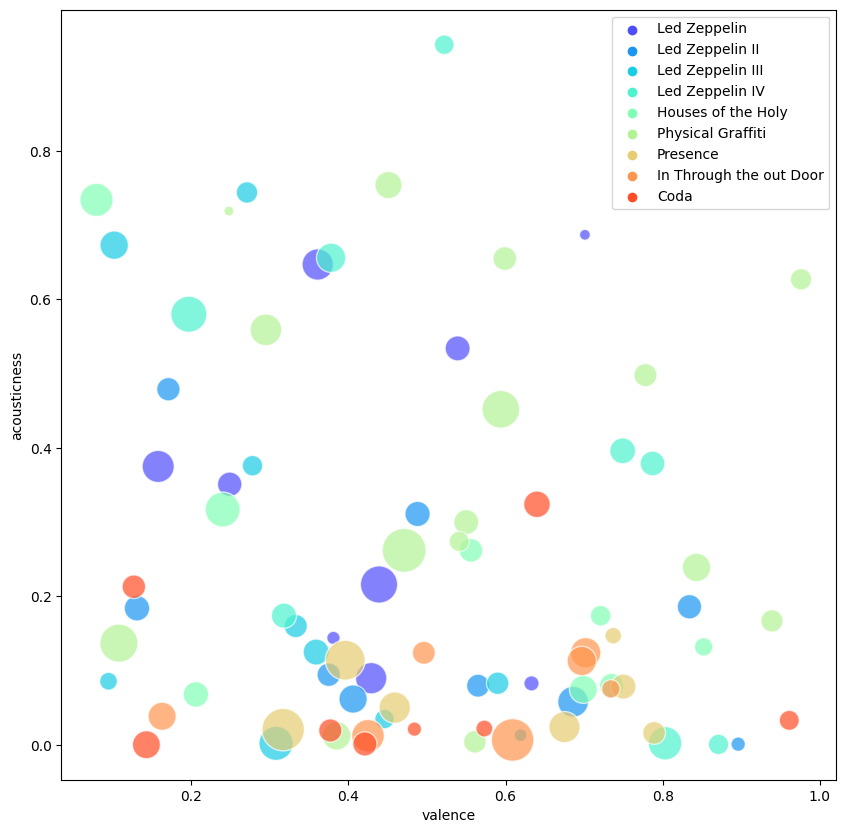

In [33]:
plt.figure(figsize=(10,10))

ax = sns.scatterplot(data=df, x='valence', y='acousticness', 
                     hue='short_album_name', palette='rainbow', 
                     size='duration_ms', sizes=(50,1000), 
                     alpha=0.7)

# display legend without `size` attribute
h,labs = ax.get_legend_handles_labels()
ax.legend(h[1:10], labs[1:10], loc='best', title=None)

Interesting to see how much these guys shifted away from the folk-inspired acoustic tracks in later albums, how a lot of their “saddest” pieces are acoustic, and how varied they are overall — the scatter covers almost the whole 1x1 plot! 

This is only capturing 1 interaction though … we could keep plotting pairs of attributes … OR, we could try to find a 2-dimensional “embedding” of the entire dataset so that if two tracks are “similar” across all dimensions, they will appear “close” in the 2-dimensional scatter.

There are many approaches to this problem of “dimensionality reduction” — for example, Principal Component Analysis (PCA) is a classic method that projects points onto a lower-dimensional hyperplane in a way that maximizes the explained variance, but it’s limited in that it is strictly linear. We could instead find/learn a nonlinear surface on which to project the points, like various “manifold learning” techniques.

Let’s do this with the popular t-SNE algorithm from scikit-learn.


In [55]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# extract relevant columns to numpy array
X = (df
 .filter(['acousticness', 'danceability', 'duration_ms', 'energy',
          'instrumentalness', 'liveness', 'loudness', 'tempo', 'valence'])
)

# algo will do better if data is standardized (zero mean, unit variance)
Xs = StandardScaler().fit_transform(X)

/home/cesar/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/cesar/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/cesar/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/cesar/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if

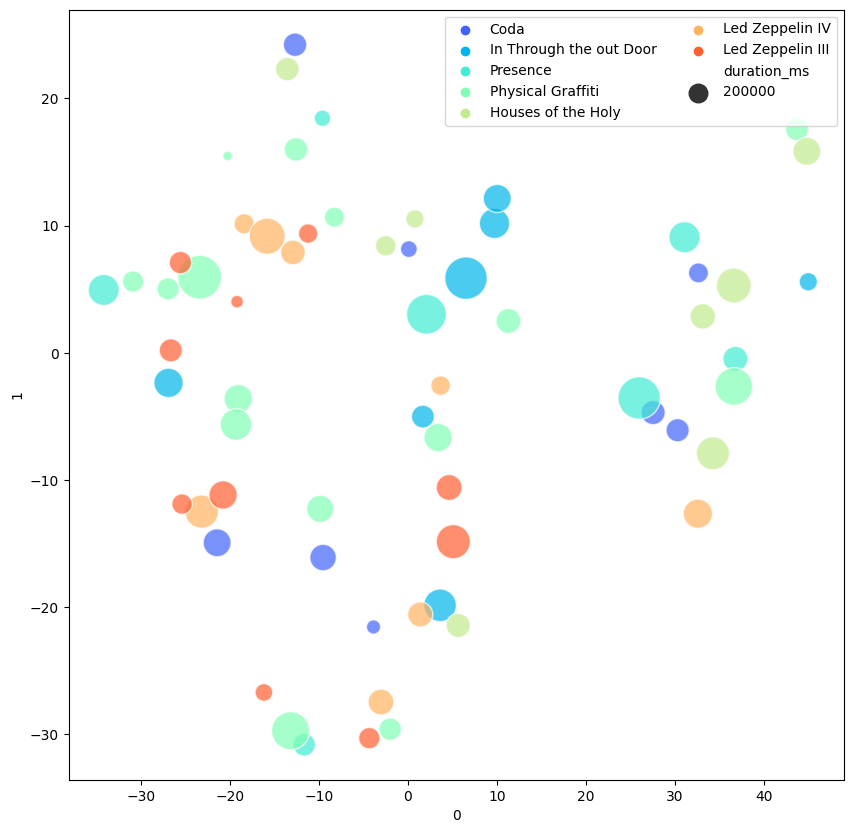

In [56]:
# construct 2-d embedding
tsne = TSNE(n_components=2, perplexity=6, 
    early_exaggeration=1, random_state=3).fit_transform(Xs)

# convert to dataframe for plotting purposes
tsne = pd.DataFrame(tsne)
tsne['short_album_name'] = df['short_album_name']
tsne['duration_ms'] = df['duration_ms']

plt.figure(figsize=(10,10))

ax = sns.scatterplot(data=tsne, x=0, y=1, 
                     hue='short_album_name', palette='rainbow', 
                     size='duration_ms', sizes=(50,1000), 
                     alpha=0.7)

# display legend without `size` attribute
h,labs = ax.get_legend_handles_labels()
ax.legend(h[1:10], labs[1:10], loc='best', ncol=2)

plt.show()

And with multidimensional Scaling

/home/cesar/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/cesar/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/cesar/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/cesar/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if

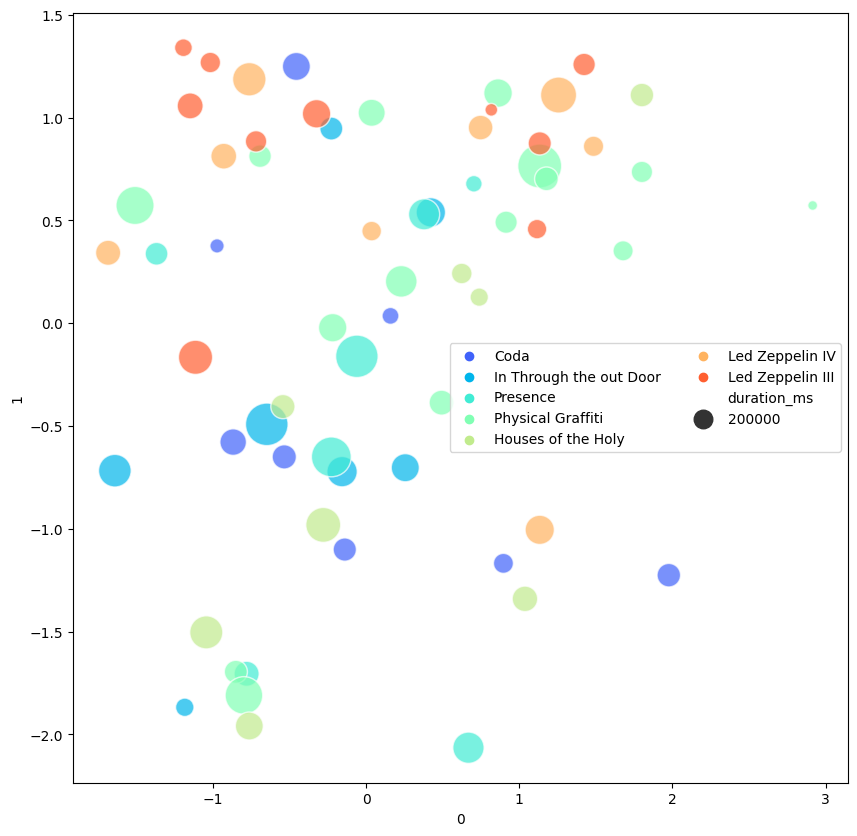

In [61]:
embedding = MDS(n_components=2, normalized_stress='auto')
X_transformed = embedding.fit_transform(Xs)
# convert to dataframe for plotting purposes
tsne = pd.DataFrame(Xs)
tsne['short_album_name'] = df['short_album_name']
tsne['duration_ms'] = df['duration_ms']

plt.figure(figsize=(10,10))

ax = sns.scatterplot(data=tsne, x=0, y=1, 
                     hue='short_album_name', palette='rainbow', 
                     size='duration_ms', sizes=(50,1000), 
                     alpha=0.7)

# display legend without `size` attribute
h,labs = ax.get_legend_handles_labels()
ax.legend(h[1:10], labs[1:10], loc='best', ncol=2)

plt.show()